In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
import sys
import cv2

sys.path.append(r"C:\Users\sjefs\Desktop\Uni\Speciale\Kode\library")
import CV_functions as CV_func
import CV_classes as CV_class
from PIL import Image
from PIL.TiffTags import TAGS
import matplotlib.pyplot as plt
import random

# The point of it all
Here the idea is to put together some of the stuff i found from CV_tools_sharang_data, and pack it toether into a pipeline. This document only works with analysing the marked chromosomes in the images.

The pipeline should be like:
1. Load the image.
2. Preprocess the image (blur and normalize).
3. Apply adaptive thresholding.
4. Get marked points.
5. Perform region growing to get segments.
6. Identify the largest segment.
7. Calculate center of mass, area, and spread for the largest segment.
8. Store the results.
9. Visualize the results.


I want to expand into:

Channel 1
1. Load image of chromosomes in channel 1.
2. Preprocess the image (blur and normalize).
3. Apply adaptive thresholding.
4. Get marked points.
5. Perform region growing to get segments.
6. Identify the largest segment.
7. Calculate center of mass, area, and spread for the largest segment.
8. Store the results.

Channel 2
1. Crop the image to region of interest, around the largest segment

# Building pipeline components
## Loading image and preprocessing it

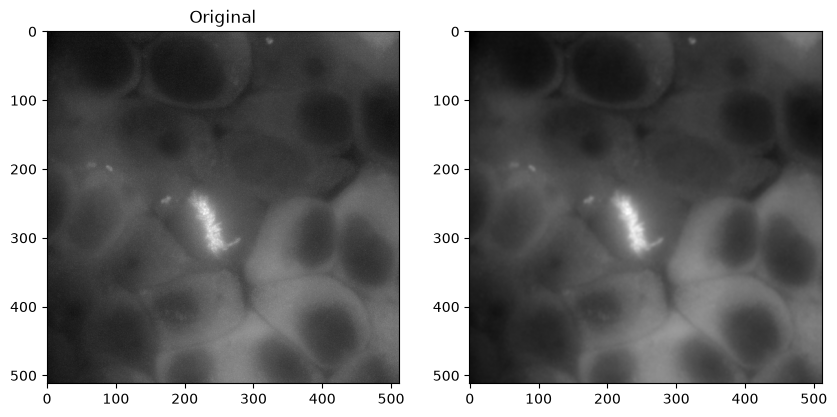

In [2]:
# Loadin Image and running some preprocessing
image_number = 10
Image_1 = CV_func.load_image("timelapze_z", number = image_number, channel = 1)
Image_1.blur(ksize = (5, 5), sigma = 1.4)
Image_1.gray()
Image_1.normalize()
#Image.contrast(clip_limit=1.0, tile_grid_size=(8,8))




# Plot it
if True:
    plt.figure(figsize=(10,5))
    plt.subplot(1, 2, 1)
    plt.imshow(Image_1.array_original, cmap='gray')
    plt.title('Original')
    plt.subplot(1, 2, 2)
    plt.imshow(Image_1.array, cmap='gray')




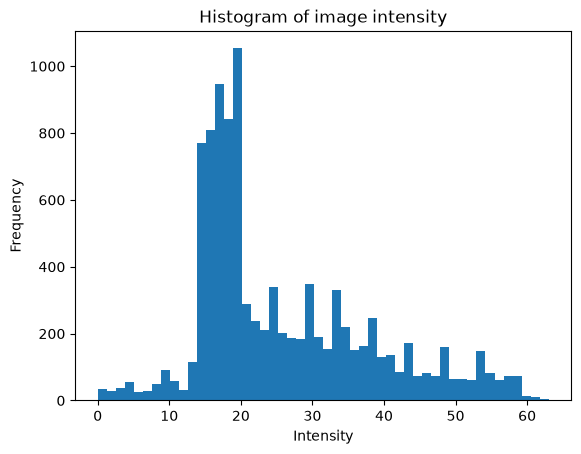

In [3]:
Image_1.downsize(100)
plt.hist(Image_1.array.ravel(), bins=50)
plt.title("Histogram of image intensity")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.savefig("histogram of intensities.png")
print("")

In [4]:
# Crop a 150x150 region around the chromosome's center of mass
x_center, y_center = map(int, center_of_mass)
half_size = 75

image = Image_1.array
height, width = image.shape[:2]

x_min = max(0, x_center - half_size)
x_max = min(width, x_center + half_size)
y_min = max(0, y_center - half_size)
y_max = min(height, y_center + half_size)

Image_1.array = image[y_min:y_max, x_min:x_max].copy()

plt.imshow(Image_1.array, cmap="gray")
plt.axis("off")
plt.title("Centered crop")


NameError: name 'center_of_mass' is not defined

[[ 70  70  70 ...  58  58  57]
 [ 71  71  71 ...  58  58  57]
 [ 72  72  72 ...  59  58  58]
 ...
 [ 84  85  86 ... 131 133 134]
 [ 85  85  86 ... 131 133 135]
 [ 85  85  86 ... 131 133 135]]



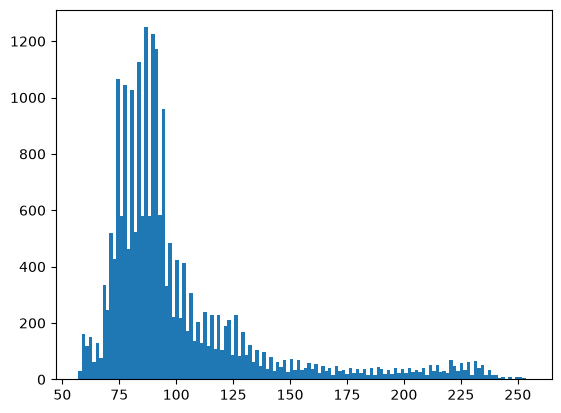

In [200]:
plt.hist(Image_1.array.ravel(), bins=130)
print(Image_1.array)
print("")

uint16 (512, 512)


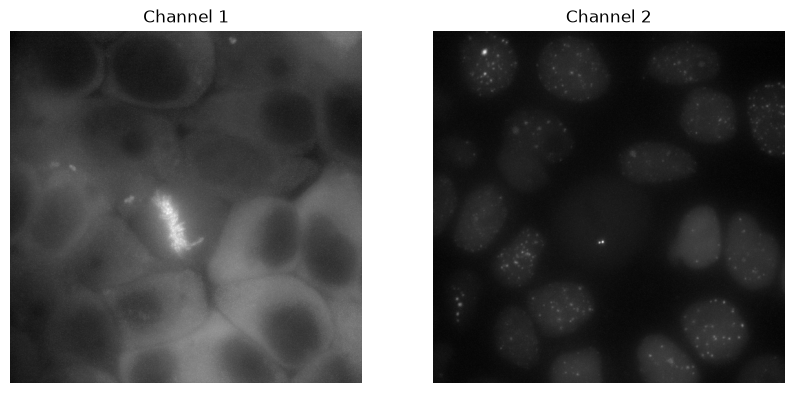

In [5]:
image_number = 10
# Generatin a comparisson of the two channels for writing
Image_1 = CV_func.load_image("timelapze_z", number = image_number, channel = 1)
Image_2 = CV_func.load_image("timelapze_z", number = image_number, channel = 2)

print(Image_1.array.dtype, Image_1.array.shape)

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(Image_1.array_original, cmap='gray')
plt.title('Channel 1')
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(Image_2.array_original, cmap='gray')
plt.title('Channel 2')
plt.axis("off")
plt.savefig("Comparin channels z-proj.png")

## Detecting chromosome pixels

Here we use a simple adaptive thresholding technique to segment the image.

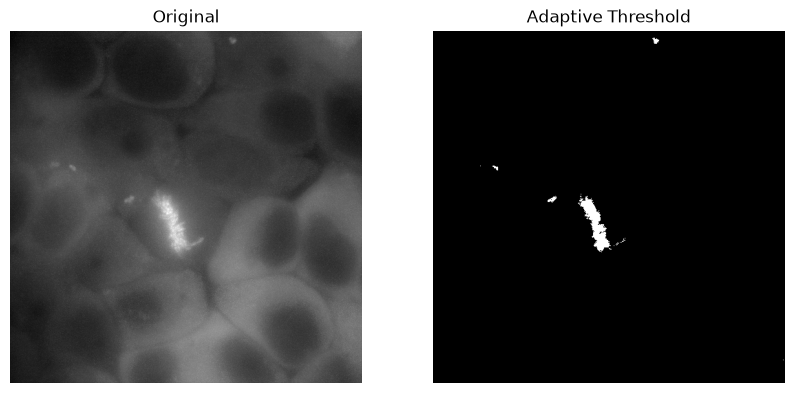

In [6]:
th1 = Image_1.adaptive_threshold(block_size=101, C=-30)

# Display original and th1 side by side
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(Image_1.array_original, cmap='gray')
plt.title('Original')
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(th1, cmap='gray')
plt.title('Adaptive Threshold')
plt.axis("off")
plt.savefig("Adaptive_Threshold_Image_1.png")

## Segmenting chromosome regions
Lets segment into different parts. Here the idea is to grow the area. Essentially selecting a point, and keeping its neightbours if they belong to the foreground, until all neighboring points have been considered.

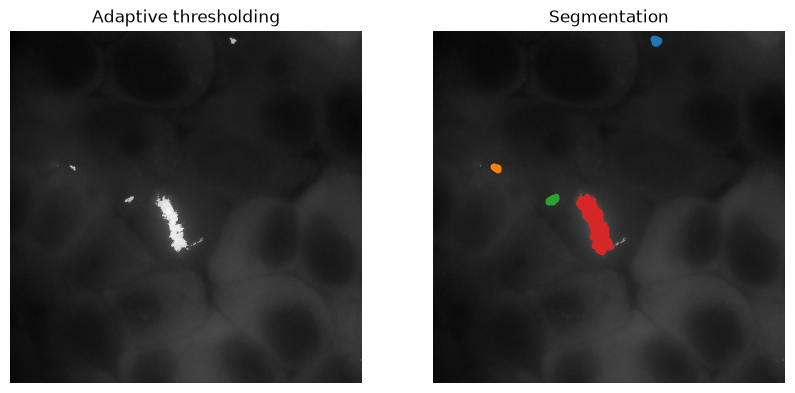

In [7]:
# We start by selecting all foreground points as potential starting points for region growing.
marked_points = CV_func.get_marked_points(th1)

# Use marked_points as the potential starting points.
segments = CV_func.region_growing(th1, marked_points, min_size=10)

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(th1, cmap="gray")
plt.imshow(Image_1.array_original, cmap="gray", alpha=0.5)
plt.title("Adaptive thresholding")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(th1, cmap="gray")
plt.title("Segmentation")
plt.imshow(Image_1.array_original, cmap="gray", alpha=0.5)
plt.axis("off")
for segment in segments:
    plt.scatter(
        [p[0] for p in segment],
        [p[1] for p in segment],
        marker=".",
    )
plt.axis("off")
plt.savefig("Region_Growing_Image_1.png")

## Working with largest segment

Now with all of the segnemts, we can choose the largest one, and calculate its center of mass and area

(224, 241)
Center of Mass: (236.16261398176292, 280.7317629179331)


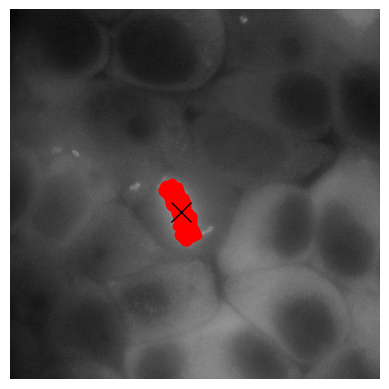

In [8]:
largest_segment = CV_func.get_largest_segment(segments)
center_of_mass = CV_func.get_center_of_mass(largest_segment)
area = CV_func.get_area(largest_segment)
largest_segment_array = np.asarray(largest_segment)

# Plot largest segment on top of the original image
print(largest_segment[1])
plt.imshow(Image_1.array_original, cmap='gray')
plt.scatter(largest_segment_array[:, 0], largest_segment_array[:, 1], color = "r")
print("Center of Mass:", center_of_mass)
# Plot center of mass as a cross
plt.plot(center_of_mass[0], center_of_mass[1], 'x', color = "black", markersize=15)
plt.axis("off")
plt.savefig("Largest_Segment_Image_1.png")

## Moving into channel 2 and cropping
Now we need to select the area of interest. This should be related to the area covered by the chromosomes. 
Goes as:
1. Get the bounding box of the largest segment.
2. Calculate the center of mass of the largest segment.
3. Determine the corners of the bounding box.
4. Compute the radii from the center of mass to each corner.
5. Create a circle around the center of mass with a radius equal to the maximum distance to the corners.
6. Get the bounding box of the circle.

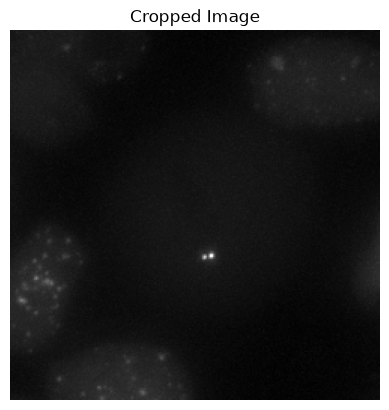

In [9]:
cropped_image = CV_func.get_bounding_box(Image_2.array_original, largest_segment_array, scale=3)
Image_2.array = cropped_image
plt.imshow(Image_2.array, cmap="gray")
plt.axis("off")
plt.title("Cropped Image")
plt.savefig("Cropped_Image_2.png")

## Running segmentation

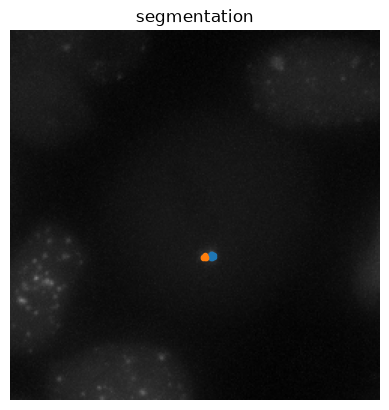

In [10]:
Image_2.normalize()
th2 = Image_2.adaptive_threshold(block_size=101, C=-100)

# Plot the adaptive threshold result on top of original
plt.imshow(Image_2.array, cmap='gray')
plt.imshow(th2, cmap='gray', alpha=0.5)

marked_points_2 = CV_func.get_marked_points(th2)
segments_2 = CV_func.region_growing(th2, marked_points_2)

# Plot the segmented regions on top of the original image
plt.imshow(Image_2.array, cmap="gray")
for segment in segments_2:
    plt.scatter(
        [p[0] for p in segment],
        [p[1] for p in segment],
        marker=".",
    )
plt.axis("off")
plt.title("segmentation")
plt.savefig("Segmentation_Image_2.png")

# Expanding to multiple images
We run the whole algorithm for each of the images in the time series, allowing us to track the evolution of the area and the center of mass over time.

The most important thing to adjust here is the C parameter in the adaptive thresholding step, as it significantly affects the segmentation results.

Using channel 2, a C factor of 0.1, actually makes us detect all the dark blobs as segments. I dont know why this is

Channel 1 works nicely with a C factor of 0.3

## Channel 1

In [ ]:
from ipywidgets import interact, IntSlider
from matplotlib.pyplot import gray

N_images = 10
channel = 1
C_factor = 0.3

# Setup some arrays for storing results
center_of_mass_array = np.zeros((N_images, 2))
area_array = np.zeros(N_images)
largest_segment_array = np.zeros(N_images, dtype = object)
all_segments = []
spread_array = np.zeros((N_images, 2))

# Måske tilføj rotation som statistik


# Full image processing for each image
for i in range(N_images):
    # Load image and preprocess
    Image = CV_func.load_image("timelapze_z", number = i+1, channel = channel)
    Image.blur(ksize=(5, 5), sigma=1.4)
    Image.normalize()

    # Adaptive thresholding. Fixing to image average
    average = Image.average()
    C = -int(average*C_factor)
    th = Image.adaptive_threshold(block_size=101, C=C)


    # Segmenting the image using region growing
    marked_points = CV_func.get_marked_points(th)
    segments = CV_func.region_growing(th, marked_points, min_size=10)
    largest_segment = CV_func.get_largest_segment(segments)

    # Storing some values
    all_segments.append(segments)
    largest_segment_array[i] = largest_segment

    # Calculating some statistics
    center_of_mass = CV_func.get_center_of_mass(largest_segment)
    area = CV_func.get_area(largest_segment)
    spread = CV_func.get_spread(largest_segment)

    # Storing the calculated statistics
    center_of_mass_array[i] = center_of_mass
    area_array[i] = area
    spread_array[i] = spread


def plot_frame(i):
    image = CV_func.load_image(
        "timelapze_z",
        number=i + 1,
        channel=channel,
    )

    fig = plt.figure(figsize=(6, 6))
    plt.imshow(image.array_original, cmap="gray")

    for segment in all_segments[i]:
        CV_func.plot_segment(segment)

    com = center_of_mass_array[i]
    plt.plot(com[0], com[1], "rx", markersize=12, markeredgewidth=3)

    plt.title(f"Image {i}")
    plt.axis("off")
    plt.show()
    plt.close(fig)


interact(
    plot_frame,
    i=IntSlider(min=0, max=N_images - 1, step=1, value=0),
)

# Now lets convert the interactible plot into a gif for my slide
if False:
    import imageio
    from IPython.display import display

    with imageio.get_writer(
        "timelapse.gif",
        mode="I",
        duration=1.0,
        loop=9,  # 10 total plays
    ) as writer:
        for i in range(N_images):
            Image = CV_func.load_image("timelapze_z", number=i + 1, channel=channel)

            plt.figure(figsize=(6, 6))
            plt.imshow(Image.array_original, cmap="gray")

            for segment in all_segments[i]:
                CV_func.plot_segment(segment)

            com = center_of_mass_array[i]
            plt.plot(com[0], com[1], "rx", markersize=12, markeredgewidth=3)
            plt.title(f"Image {i}")
            plt.axis("off")
            plt.savefig(f"frame_{i}.png")
            plt.close()

            writer.append_data(imageio.imread(f"frame_{i}.png"))

    for i in range(N_images):
        os.remove(f"frame_{i}.png")

interactive(children=(IntSlider(value=0, description='i', max=9), Output()), _dom_classes=('widget-interact',)…

### Statistics

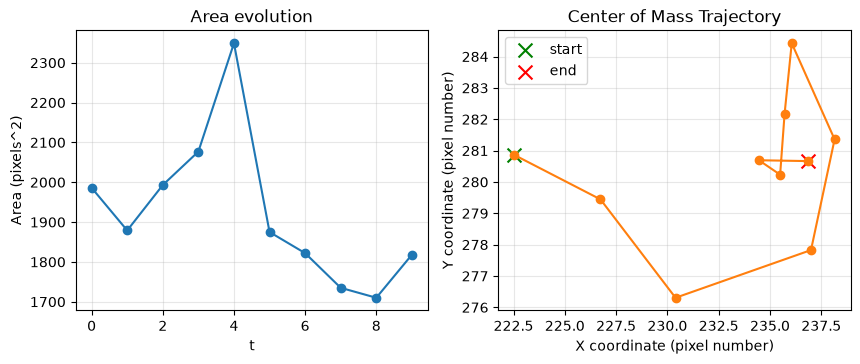

In [28]:
plt.figure(figsize =(10, 8))
plt.subplot(2, 2, 1)
plt.plot(np.arange(N_images), area_array, marker="o", color="tab:blue")
plt.xlabel("t")
plt.ylabel("Area (pixels^2)")
plt.title("Area evolution")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
# plot trajectory of the center of mass, marking the start point
plt.plot(
    [com[0] for com in center_of_mass_array],
    [com[1] for com in center_of_mass_array],
    marker="o",
    color="tab:orange"
)
plt.scatter(center_of_mass_array[0][0], center_of_mass_array[0][1], color="green", marker="x", s=100, label = "start")
plt.scatter(center_of_mass_array[-1][0], center_of_mass_array[-1][1], color="red", marker="x", s=100, label = "end")
plt.xlabel("X coordinate (pixel number)")
plt.ylabel("Y coordinate (pixel number)")
plt.title("Center of Mass Trajectory")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Channel 1 Statistics.png")

#plt.subplot(2, 2, 3)
#plt.plot(np.arange(N_images), spread_array[:, 0], marker="o", color="tab:green", label="X spread")
#plt.plot(np.arange(N_images), spread_array[:, 1], marker="o", color="tab:red", label="Y spread")
#plt.xlabel("Frame")
#plt.ylabel("Spread (pixels)")
#plt.title("Spread evolution")
#plt.legend()
#plt.grid(True, alpha=0.3)

## Channel 2
We do the pipeline:
1. Find bounding box of largest segment from image 1
2. Use this bounding box to crop the region of interest in image 2
3. apply adaptive thresholding
4. apply region growing to find segments within the cropped region

In [ ]:
Image = CV_func.load_image("timelapze_z", number = i+1, channel = channel)
Image.normalize()

cropped_image = CV_func.get_bounding_box(Image.array_original, largest_segment_array[i], scale=3)
Image.array = cropped_image

average = Image.average()
C = -int(average*C_factor)

th = Image.adaptive_threshold(block_size=51, C=C)
marked_points = CV_func.get_marked_points(th)
segments = CV_func.region_growing(th, marked_points, min_size=1)

In [30]:
channel = 2
C_factor = 0.25
all_segments_2 = []
for i in range(N_images):
    Image = CV_func.load_image("timelapze_z", number = i+1, channel = channel)
    Image.normalize()

    cropped_image = CV_func.get_bounding_box(Image.array_original, largest_segment_array[i], scale=3)
    Image.array = cropped_image

    average = Image.average()
    C = -int(average*C_factor)

    th = Image.adaptive_threshold(block_size=51, C=C)

    marked_points = CV_func.get_marked_points(th)
    segments = CV_func.region_growing(th, marked_points, min_size=1)
    all_segments_2.append(segments)

    def plot_frame(i):
        Image = CV_func.load_image("timelapze_z", number = i+1, channel = channel)
        Image.normalize()
        cropped_image = CV_func.get_bounding_box(Image.array_original, largest_segment_array, scale=3)
        Image.array = cropped_image
        plt.figure(figsize=(6, 6))
        plt.imshow(Image.array, cmap='gray')
        for segment in all_segments_2[i]:
            CV_func.plot_segment(segment)



        plt.title(f"Image {i}")
        plt.axis("off")

interact(plot_frame, i=IntSlider(min=0, max=N_images-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i', max=9), Output()), _dom_classes=('widget-interact',)…

<function __main__.plot_frame(i)>

In [4]:
channel = 2
C_factor = 0.20
all_segments_2 = [[] for _ in range(N_images)]

for i in range(N_images):
    Image = CV_func.load_image("timelapze_z", number=i+1, channel=channel)
    Image.normalize()

    # Use the largest segment from channel 1 (same frame) to crop
    cropped_image = CV_func.get_bounding_box(
        Image.array_original,
        np.asarray(largest_segments[i]),
        scale=3
    )
    Image.array = cropped_image

    average = Image.average()
    C = -int(average * C_factor)

    th = Image.adaptive_threshold(block_size=51, C=C)

    marked_points = CV_func.get_marked_points(th)
    segments = CV_func.region_growing(th, marked_points, min_size=1)
    all_segments_2[i] = segments


def plot_frame_2(i):
    Image = CV_func.load_image("timelapze_z", number=i+1, channel=channel)
    Image.normalize()
    cropped_image = CV_func.get_bounding_box(
        Image.array_original,
        np.asarray(largest_segments[i]),
        scale=3
    )
    Image.array = cropped_image
    fig = plt.figure(figsize=(6, 6))
    plt.imshow(Image.array, cmap='gray')
    for segment in all_segments_2[i]:
        CV_func.plot_segment(segment)

    plt.title(f"Image {i}")
    plt.axis("off")
    plt.show()
    plt.close(fig)


interact(plot_frame_2, i=IntSlider(min=0, max=N_images-1, step=1, value=0))

if False:
    # Convert to a gif
    import imageio

    with imageio.get_writer(
        "timelapse_channel2.gif",
        mode="I",
        duration=1.0,
        loop=0,
    ) as writer:
        for i in range(N_images):
            Image = CV_func.load_image("timelapze_z", number=i+1, channel=channel)
            Image.normalize()
            cropped_image = CV_func.get_bounding_box(
                Image.array_original,
                np.asarray(largest_segments[i]),
                scale=3
            )
            Image.array = cropped_image

            plt.figure(figsize=(6, 6))
            plt.imshow(Image.array, cmap='gray')
            for segment in all_segments_2[i]:
                CV_func.plot_segment(segment)

            plt.title(f"Image {i}")
            plt.axis("off")
            plt.savefig(f"frame2_{i}.png")
            plt.close()

            writer.append_data(imageio.imread(f"frame2_{i}.png"))

    for i in range(N_images):
        os.remove(f"frame2_{i}.png")

interactive(children=(IntSlider(value=0, description='i', max=24), Output()), _dom_classes=('widget-interact',…

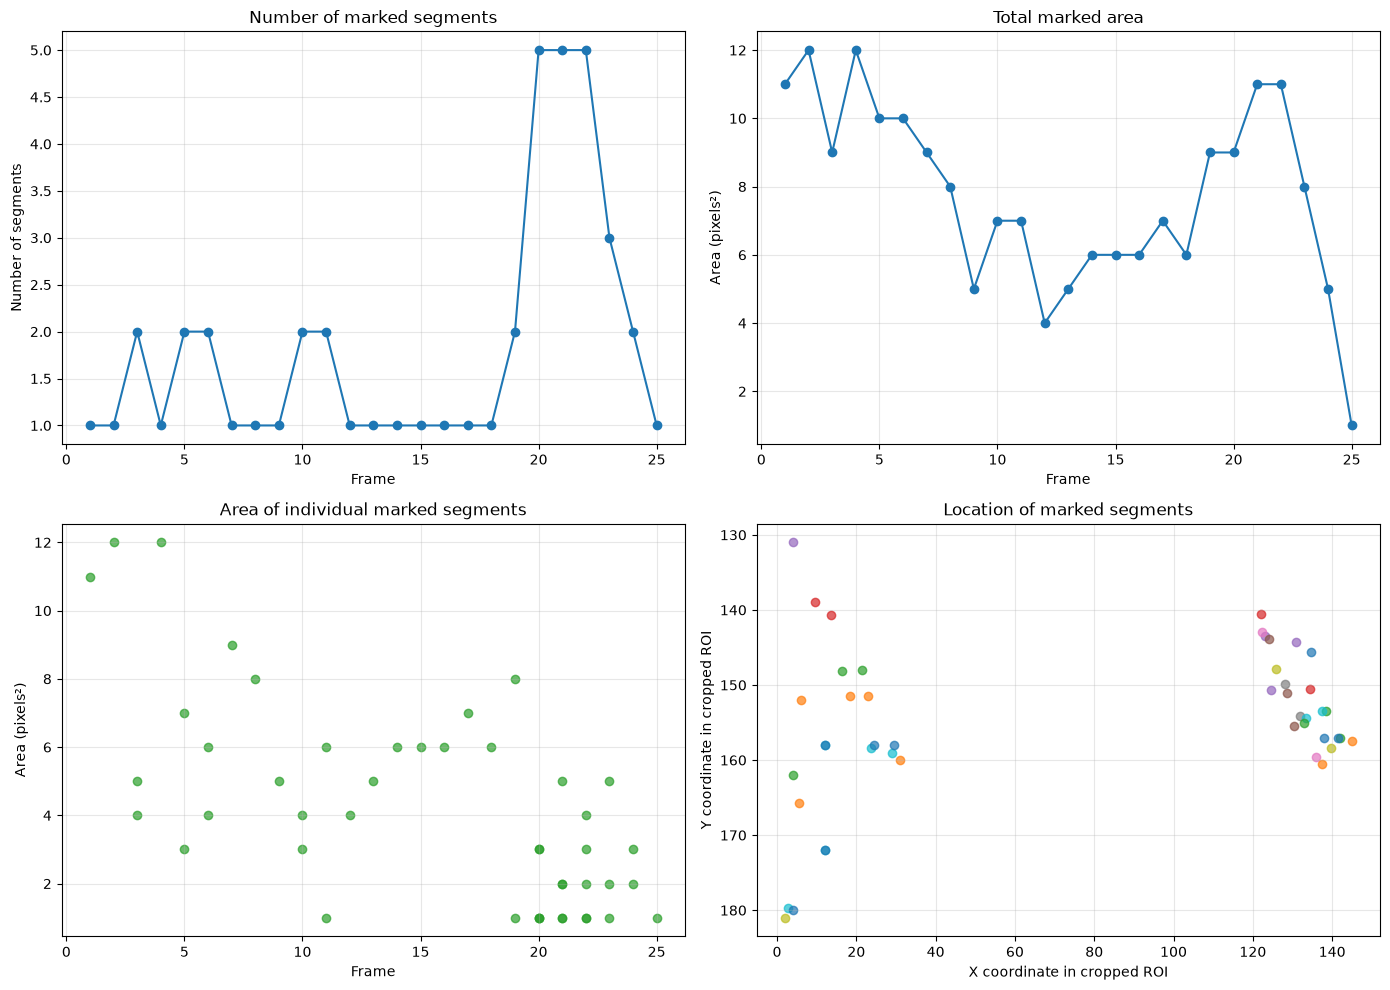

Frame 1:
  Segment 1: area=11 pixels², center=(134.73, 145.55)
Frame 2:
  Segment 1: area=12 pixels², center=(144.92, 157.42)
Frame 3:
  Segment 1: area=4 pixels², center=(138.50, 153.50)
  Segment 2: area=5 pixels², center=(142.00, 157.00)
Frame 4:
  Segment 1: area=12 pixels², center=(134.50, 150.50)
Frame 5:
  Segment 1: area=7 pixels², center=(131.00, 144.29)
  Segment 2: area=3 pixels², center=(124.67, 150.67)
Frame 6:
  Segment 1: area=6 pixels², center=(128.50, 151.00)
  Segment 2: area=4 pixels², center=(130.50, 155.50)
Frame 7:
  Segment 1: area=9 pixels², center=(135.89, 159.56)
Frame 8:
  Segment 1: area=8 pixels², center=(131.88, 154.12)
Frame 9:
  Segment 1: area=5 pixels², center=(139.80, 158.40)
Frame 10:
  Segment 1: area=4 pixels², center=(137.50, 153.50)
  Segment 2: area=3 pixels², center=(133.33, 154.33)
Frame 11:
  Segment 1: area=6 pixels², center=(141.50, 157.00)
  Segment 2: area=1 pixels², center=(138.00, 157.00)
Frame 12:
  Segment 1: area=4 pixels², center=(1

In [24]:
# Channel 2 statistics: area and location of every marked segment
segment_counts_2 = np.zeros(N_images, dtype=int)
total_area_2 = np.zeros(N_images, dtype=int)
segment_areas_2 = []
segment_centers_2 = []

for frame, frame_segments in enumerate(all_segments_2):
    areas = []
    centers = []

    for segment in frame_segments:
        points = np.asarray(segment)

        if points.size == 0:
            continue

        areas.append(len(segment))
        centers.append(points.mean(axis=0))  # (x, y)

    segment_counts_2[frame] = len(areas)
    total_area_2[frame] = sum(areas)
    segment_areas_2.append(areas)
    segment_centers_2.append(centers)

# Statistics page
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

frames = np.arange(1, N_images + 1)

axes[0, 0].plot(frames, segment_counts_2, marker="o")
axes[0, 0].set_title("Number of marked segments")
axes[0, 0].set_xlabel("Frame")
axes[0, 0].set_ylabel("Number of segments")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(frames, total_area_2, marker="o", color="tab:blue")
axes[0, 1].set_title("Total marked area")
axes[0, 1].set_xlabel("Frame")
axes[0, 1].set_ylabel("Area (pixels²)")
axes[0, 1].grid(alpha=0.3)

# Area of each segment in every frame
for frame, areas in enumerate(segment_areas_2, start=1):
    axes[1, 0].scatter(
        [frame] * len(areas),
        areas,
        color="tab:green",
        alpha=0.7
    )

axes[1, 0].set_title("Area of individual marked segments")
axes[1, 0].set_xlabel("Frame")
axes[1, 0].set_ylabel("Area (pixels²)")
axes[1, 0].grid(alpha=0.3)

# Location of every segment in cropped-image coordinates
for frame, centers in enumerate(segment_centers_2, start=1):
    if centers:
        centers = np.asarray(centers)
        axes[1, 1].scatter(
            centers[:, 0],
            centers[:, 1],
            label=f"Frame {frame}",
            alpha=0.7
        )

axes[1, 1].set_title("Location of marked segments")
axes[1, 1].set_xlabel("X coordinate in cropped ROI")
axes[1, 1].set_ylabel("Y coordinate in cropped ROI")
axes[1, 1].invert_yaxis()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Channel 2 Statistics.png")
plt.show()

# Print per-frame segment statistics
for frame in range(N_images):
    print(f"Frame {frame + 1}:")
    for number, (area_value, center_value) in enumerate(
        zip(segment_areas_2[frame], segment_centers_2[frame]),
        start=1
    ):
        print(
            f"  Segment {number}: "
            f"area={area_value} pixels², "
            f"center=({center_value[0]:.2f}, {center_value[1]:.2f})"
        )